R²: 0.999049
MAE: 2961.55 (0.56%)
RMSE: 5504.34 (1.03%)


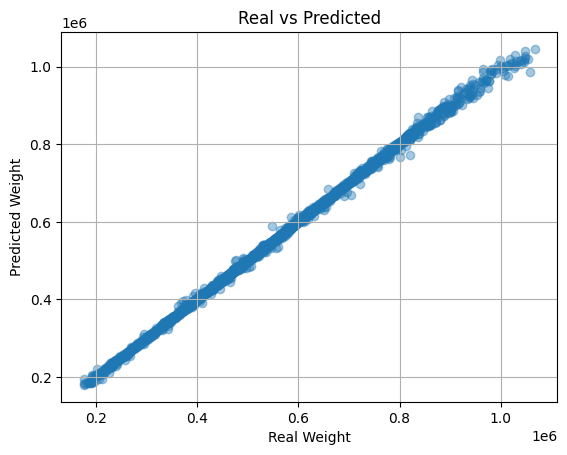

In [2]:
#Q1
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 
import pandas as pd
from sklearn.preprocessing import LabelEncoder


machine = pd.read_csv('data/Machine_Settings_Log_01.csv')
production = pd.read_csv('data/Production_Log_01.csv')


df = production.merge(machine, on='configuration_log_ID', how='inner')

df = df.drop(columns=['weight_in_g', 'id'], axis=1)

df_encoded = df.copy()
label_encoders = {}

for col in ['ionizationclass', 'FluxCompensation','error_type', 'multideminsionality']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le


lowerWaste = df_encoded['weight_in_kg'].quantile(0.01)
upperWaste = df_encoded['weight_in_kg'].quantile(0.99)
df_filtered = df_encoded[(df_encoded['weight_in_kg'] >= lowerWaste) & (df_encoded['weight_in_kg'] <= upperWaste)]


X_reg = df_filtered.drop(columns=['weight_in_kg', 'error', 'error_type'])
Y_reg = df_filtered['weight_in_kg']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_reg, Y_reg, random_state=42, shuffle=True, test_size=0.3)

model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_reg.fit(Xtrain, Ytrain)
Ypred = model_reg.predict(Xtest)

mae = mean_absolute_error(Ytest, Ypred)
rmse = np.sqrt(mean_squared_error(Ytest, Ypred))
mean_val = Ytest.mean()
mae_pct = (mae / mean_val) * 100
rmse_pct = (rmse / mean_val) * 100
r2 = r2_score(Ytest, Ypred)

print(f"R²: {r2:.6f}")
print(f"MAE: {mae:.2f} ({mae_pct:.2f}%)")
print(f"RMSE: {rmse:.2f} ({rmse_pct:.2f}%)")


import matplotlib.pyplot as plt

plt.scatter(Ytest, Ypred, alpha=0.4)
plt.xlabel("Real Weight")
plt.ylabel("Predicted Weight")
plt.title("Real vs Predicted")
plt.grid(True)
plt.show()



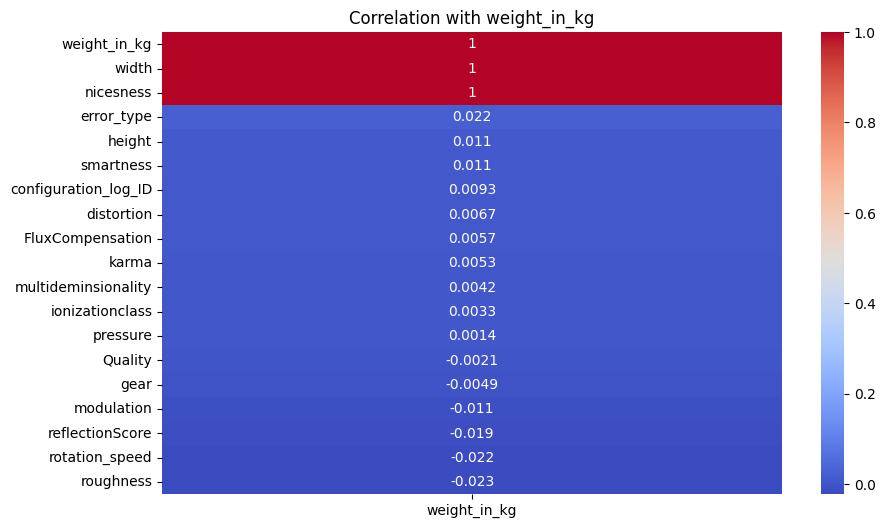

In [3]:
#Feature Exploring for Q1
import seaborn as sns
import matplotlib.pyplot as plt

correlations = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlations[["weight_in_kg"]].sort_values(by="weight_in_kg", ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlation with weight_in_kg")
plt.show()



In [4]:
#Feature Engineering for Q1
df_encoded["area"] = df_encoded["width"] * df_encoded["height"]
df_encoded["log_weight"] = np.log1p(df_encoded["weight_in_kg"])

print(df_encoded.describe())

              width        height  ionizationclass  FluxCompensation  \
count  1.000000e+04  10000.000000     10000.000000      10000.000000   
mean   2.000011e+07     42.001636         0.996100          1.505900   
std    4.467885e+08      2.015463         0.815813          1.119862   
min    3.086553e+01     35.093287         0.000000          0.000000   
25%    9.614221e+01     40.650189         0.000000          1.000000   
50%    1.098902e+02     42.007901         1.000000          2.000000   
75%    1.233109e+02     43.360433         2.000000          3.000000   
max    1.000000e+10     49.325927         2.000000          3.000000   

           pressure         karma    modulation  configuration_log_ID  \
count  10000.000000  10000.000000  10000.000000           10000.00000   
mean      99.983656    998.816837    100.015683            5000.50000   
std        3.013366     98.810735      2.991423            2886.89568   
min       89.049069    663.972927     88.292365            

The metrics presented above were obtained after excluding extreme outliers that showed substantial deviation compared to the rest of the dataset.
To understand the impact of this preprocessing step, let's now **evaluate the model without applying any data filtering**.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 
import pandas as pd
from sklearn.preprocessing import LabelEncoder


machine = pd.read_csv('data/Machine_Settings_Log_01.csv')
production = pd.read_csv('data/Production_Log_01.csv')

df = production.merge(machine, on='configuration_log_ID', how='inner')

df = df.drop(columns=['weight_in_g', 'id'], axis=1)

df_encoded = df.copy()
label_encoders = {}

for col in ['ionizationclass', 'FluxCompensation','error_type', 'multideminsionality']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

#For now, we do not bound a data 

# lowerWaste = df_encoded['weight_in_kg'].quantile(0.01)
# upperWaste = df_encoded['weight_in_kg'].quantile(0.99)
# df_filtered = df_encoded[(df_encoded['weight_in_kg'] >= lowerWaste) & (df_encoded['weight_in_kg'] <= upperWaste)]

X_reg2 = df_encoded.drop(columns=['weight_in_kg', 'error', 'error_type'])
Y_reg2 = df_encoded['weight_in_kg']

Xtrain2, Xtest2, Ytrain2, Ytest2 = train_test_split(X_reg2, Y_reg2, random_state=42, shuffle=True, test_size=0.3)

model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_reg.fit(Xtrain2, Ytrain2)
Ypred2 = model_reg.predict(Xtest2)

mae = mean_absolute_error(Ytest2, Ypred2)
rmse = np.sqrt(mean_squared_error(Ytest2, Ypred2))


lower = Ytest2.quantile(0.01)
upper = Ytest2.quantile(0.99)
mean_val = Ytest2[(Ytest2 >= lower) & (Ytest2 <= upper)].mean()

mae_pct = (mae / mean_val) * 100
rmse_pct = (rmse / mean_val) * 100

#formatting is also broken due to big values of data
print(f"MAE: {mae:.2f} ({np.round(mae_pct, 2)}%)")
print(f"RMSE: {rmse:.2f} ({np.round(rmse_pct, 2)}%)")






MAE: 124192411740243072.00 (23421584690463.86%)
RMSE: 3988161405884962816.00 (752131783401916.1%)


As demonstrated, the presence of extreme values in the data leads to significantly inflated errors. Thus, applying data limits** is crucial** in this scenario.

              precision    recall  f1-score   support

        None       0.94      0.95      0.94      1307
    critical       0.30      0.38      0.33       243
       minor       0.28      0.25      0.27       216
      severe       0.28      0.21      0.24       234

    accuracy                           0.72      2000
   macro avg       0.45      0.45      0.45      2000
weighted avg       0.71      0.72      0.72      2000



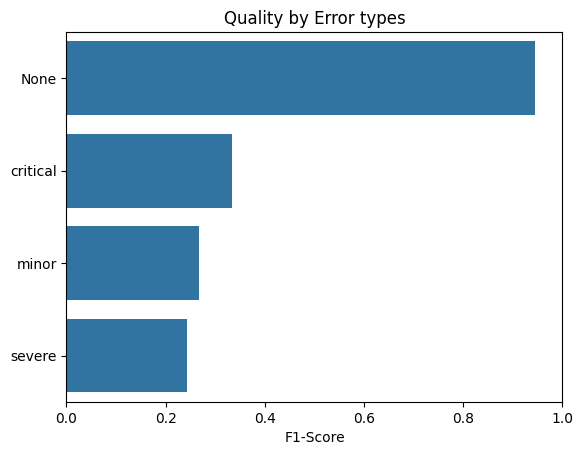

In [6]:
#Q2
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns

machine = pd.read_csv('data/Machine_Settings_Log_01.csv')
production = pd.read_csv('data/Production_Log_01.csv')

df = production.merge(machine, on='configuration_log_ID', how='inner')

df = df.drop(columns=['weight_in_g', 'id'], axis=1)

df_encoded = df.copy()
label_encoders = {}

for col in ['ionizationclass', 'FluxCompensation', 'error_type', 'multideminsionality']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded["error_type"] = df["error_type"].fillna("None").astype(str)
label_encoders["error_type"] = LabelEncoder()
df_encoded["error_type"] = label_encoders["error_type"].fit_transform(df_encoded["error_type"])

X_multi = df_encoded.drop(columns=["weight_in_kg", "error", "error_type"])
y_multi = df_encoded["error_type"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

clf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
clf_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = clf_multi.predict(X_test_multi)
target_names = label_encoders["error_type"].classes_

print(classification_report(y_test_multi, y_pred_multi, target_names=target_names))


from sklearn.metrics import classification_report
import seaborn as sns

report = classification_report(y_test_multi, y_pred_multi, output_dict=True, target_names=target_names)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in target_names}
sns.barplot(x=list(f1_scores.values()), y=list(f1_scores.keys()))
plt.xlabel("F1-Score")
plt.title("Quality by Error types")
plt.xlim(0, 1)
plt.show()



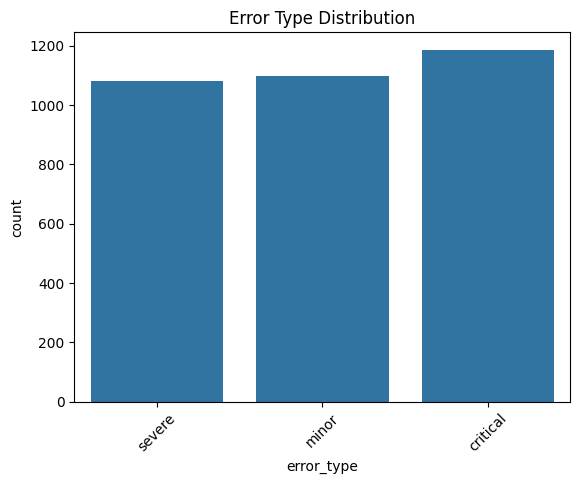

In [7]:
#Feature Exploring for Q2
sns.countplot(x="error_type", data=df)
plt.title("Error Type Distribution")
plt.xticks(rotation=45)
plt.show()



In [8]:
#Feture Engineering
df["error_type"] = df["error_type"].fillna("None")

df_encoded["is_critical_or_severe"] = df["error_type"].isin(["severe", "critical"]).astype(int)

print(df_encoded.describe())

              width        height  ionizationclass  FluxCompensation  \
count  1.000000e+04  10000.000000     10000.000000      10000.000000   
mean   2.000011e+07     42.001636         0.996100          1.505900   
std    4.467885e+08      2.015463         0.815813          1.119862   
min    3.086553e+01     35.093287         0.000000          0.000000   
25%    9.614221e+01     40.650189         0.000000          1.000000   
50%    1.098902e+02     42.007901         1.000000          2.000000   
75%    1.233109e+02     43.360433         2.000000          3.000000   
max    1.000000e+10     49.325927         2.000000          3.000000   

           pressure         karma    modulation  configuration_log_ID  \
count  10000.000000  10000.000000  10000.000000           10000.00000   
mean      99.983656    998.816837    100.015683            5000.50000   
std        3.013366     98.810735      2.991423            2886.89568   
min       89.049069    663.972927     88.292365            

              precision    recall  f1-score   support

    no error       0.94      0.95      0.95      1307
       error       0.90      0.89      0.90       693

    accuracy                           0.93      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.93      0.93      0.93      2000



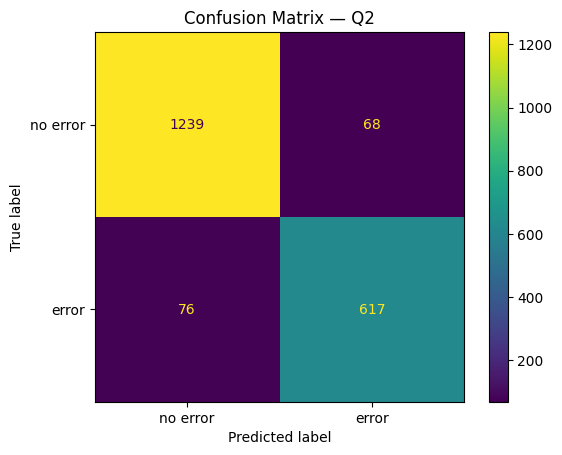

In [9]:
#Q2(alternative)
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

machine = pd.read_csv('data/Machine_Settings_Log_01.csv')
production = pd.read_csv('data/Production_Log_01.csv')

df = production.merge(machine, on='configuration_log_ID', how='inner')

df = df.drop(columns=['weight_in_g', 'id'], axis=1)

df_encoded = df.copy()
label_encoders = {}

for col in ['ionizationclass', 'FluxCompensation', 'error_type', 'multideminsionality']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

X_bin = df_encoded.drop(columns=["weight_in_kg", "error", "error_type"])
y_bin = df_encoded["error"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)

clf_bin = RandomForestClassifier(n_estimators=100, random_state=42)
clf_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = clf_bin.predict(X_test_bin)
print(classification_report(y_test_bin, y_pred_bin, target_names=["no error", "error"]))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf_bin, X_test_bin, y_test_bin, display_labels=["no error", "error"])
plt.title("Confusion Matrix — Q2")
plt.show()

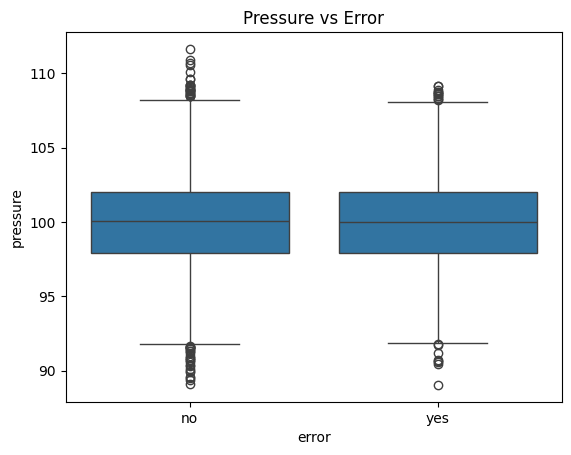

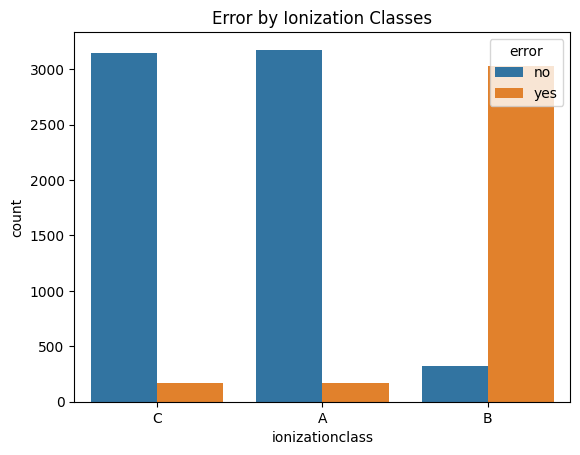

In [10]:
#Feature Exploring
sns.boxplot(x="error", y="pressure", data=df)
plt.title("Pressure vs Error")
plt.show()

sns.countplot(x="ionizationclass", hue="error", data=df)
plt.title("Error by Ionization Classes")
plt.show()


In [11]:
#Feature Engineering
df_encoded["high_pressure"] = (df_encoded["pressure"] > df_encoded["pressure"].median()).astype(int)
df_encoded["gear_speed_interaction"] = df_encoded["gear"] * df_encoded["rotation_speed"]

print(df_encoded.describe())


              width        height  ionizationclass  FluxCompensation  \
count  1.000000e+04  10000.000000     10000.000000      10000.000000   
mean   2.000011e+07     42.001636         0.996100          1.505900   
std    4.467885e+08      2.015463         0.815813          1.119862   
min    3.086553e+01     35.093287         0.000000          0.000000   
25%    9.614221e+01     40.650189         0.000000          1.000000   
50%    1.098902e+02     42.007901         1.000000          2.000000   
75%    1.233109e+02     43.360433         2.000000          3.000000   
max    1.000000e+10     49.325927         2.000000          3.000000   

           pressure         karma    modulation  configuration_log_ID  \
count  10000.000000  10000.000000  10000.000000           10000.00000   
mean      99.983656    998.816837    100.015683            5000.50000   
std        3.013366     98.810735      2.991423            2886.89568   
min       89.049069    663.972927     88.292365            

In [12]:
df_encoded

,width,height,ionizationclass,FluxCompensation,pressure,karma,modulation,configuration_log_ID,weight_in_kg,error,...,reflectionScore,distortion,nicesness,smartness,multideminsionality,roughness,gear,rotation_speed,high_pressure,gear_speed_interaction
0,137.419169,44.326218,2,3,103.937207,976.538993,98.309438,1,837068.270898,no,...,703.193051,49.666361,139.496837,2964.217002,0,123.202181,2,122.121415,1,244.242831
1,98.706037,41.619531,0,1,101.177877,1031.806826,102.748068,2,435504.324849,no,...,663.936149,52.826310,100.380138,2733.298369,1,111.040858,1,111.977476,1,111.977476
2,117.262568,41.421088,0,2,99.381956,840.246668,99.451354,3,599570.696236,no,...,674.814037,51.967423,115.995772,2716.279965,0,138.439571,1,137.268544,0,137.268544
3,122.657252,41.202308,0,0,101.833664,964.391122,101.022948,4,649889.744140,no,...,661.281569,47.626823,121.383895,2694.883523,0,125.939831,2,125.719071,1,251.438142
4,118.085366,43.418485,2,0,95.246304,859.331870,97.698503,5,605444.403997,no,...,684.026152,47.420237,118.633440,2885.260257,0,135.123613,1,134.710713,0,134.710713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,98.693482,43.223126,1,3,95.557115,1074.422817,103.228564,9996,421022.149401,no,...,665.023189,49.621868,97.779998,2868.383993,0,129.190408,1,130.355163,0,130.355163
9996,80.361968,42.414173,2,3,105.874139,922.783752,100.698130,9997,273921.656401,no,...,683.713065,50.972047,79.091321,2798.138494,0,123.402367,1,122.937046,1,122.937046
9997,104.020139,43.071501,1,1,96.444678,1080.351218,101.673757,9998,466053.196545,yes,...,704.597525,48.441531,104.778601,2854.847092,0,134.118454,1,131.985706,0,131.985706
9998,114.292997,44.874431,2,1,98.550208,949.594801,97.181766,9999,586199.631156,no,...,677.084683,50.438536,116.285367,3014.817737,0,122.684090,2,121.198563,0,242.397125


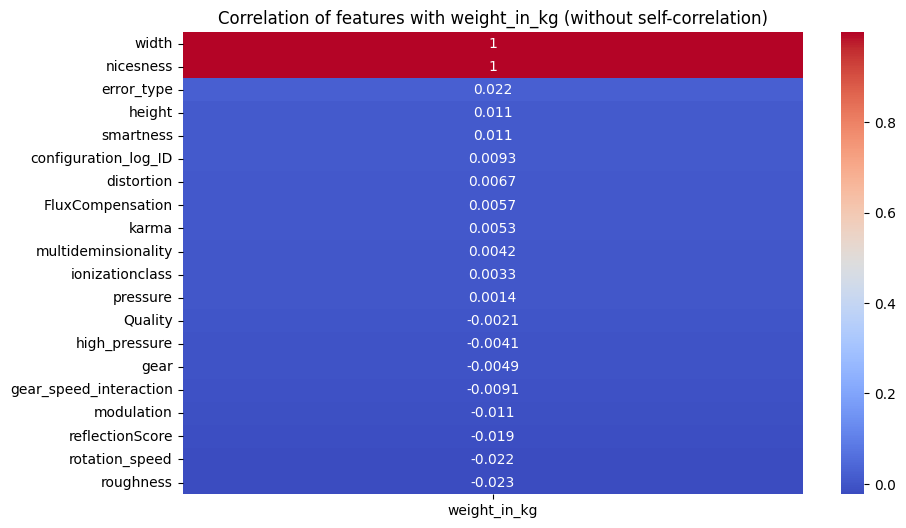

In [15]:
#Feature Exploring for Q1


import seaborn as sns
import matplotlib.pyplot as plt

correlations = df_encoded.corr(numeric_only=True)

correlations_filtered = correlations.drop(index="weight_in_kg")
correlations_sorted = correlations_filtered[["weight_in_kg"]].sort_values(by="weight_in_kg", ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(correlations_sorted, annot=True, cmap="coolwarm")
plt.title("Correlation of features with weight_in_kg (without self-correlation)")
plt.show()



/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_2157/257765132.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


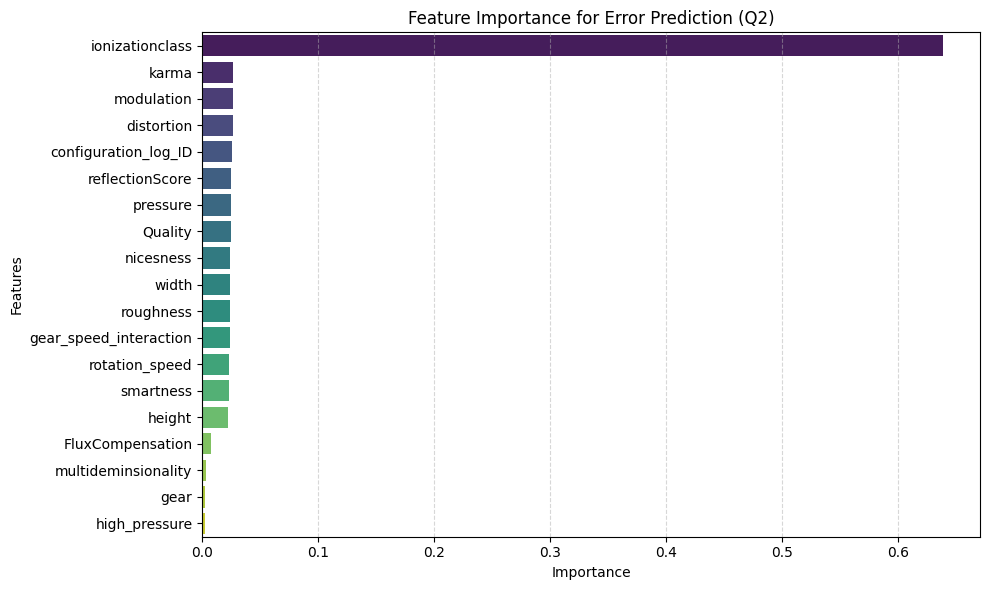

In [16]:

# ✅ Task 7 — Feature Importance Bar Chart for Q2

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["weight_in_kg", "error_type", "error"])
y = df_encoded["error"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

importances = clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance for Error Prediction (Q2)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
#Three Key Results with € Values

# Ensure binary numeric type for 'error'
if df_encoded["error"].dtype == "object":
    df_encoded["error"] = df_encoded["error"].map({"yes": 1, "no": 0})

# 1. Defects caught by the model (Q2)
total_defects = df_encoded["error"].sum()
recall = 0.89
caught_defects = total_defects * recall
saving_per_defect = 150 - 10  # €140 per caught defect
savings_q2 = caught_defects * saving_per_defect

# 2. Raw material overuse reduction (Q1)
baseline_error = 10000   # hypothetical manual setup error (kg)
mae_model = 2961         # model MAE from regression (kg)
kg_saved_per_unit = baseline_error - mae_model
units_total = len(df_encoded)

# Compute average unit weight and price per kg
avg_weight_kg = df_encoded["weight_in_kg"].mean()
price_per_kg = 10 / avg_weight_kg  # €10 per product / avg kg → €/kg

# Optional check for debugging
print(f"Average weight per unit: {avg_weight_kg:.2f} kg")
print(f"Computed price per kg: €{price_per_kg:.8f}")

savings_q1 = kg_saved_per_unit * units_total * price_per_kg

# 3. Total savings
total_savings = savings_q1 + savings_q2

# Results
print(f"Q2 - Caught defects: €{savings_q2:,.0f}")
print(f"Q1 - Material saved: €{savings_q1:,.1f}")
print(f"Total savings: €{total_savings:,.0f}")


Average weight per unit: 8488496254539545600.00 kg
Computed price per kg: €0.00000000
Q2 - Caught defects: €419,279
Q1 - Material saved: €0.0
Total savings: €419,279


In [22]:
df_encoded

,width,height,ionizationclass,FluxCompensation,pressure,karma,modulation,configuration_log_ID,weight_in_kg,error,...,reflectionScore,distortion,nicesness,smartness,multideminsionality,roughness,gear,rotation_speed,high_pressure,gear_speed_interaction
0,137.419169,44.326218,2,3,103.937207,976.538993,98.309438,1,837068.270898,0,...,703.193051,49.666361,139.496837,2964.217002,0,123.202181,2,122.121415,1,244.242831
1,98.706037,41.619531,0,1,101.177877,1031.806826,102.748068,2,435504.324849,0,...,663.936149,52.826310,100.380138,2733.298369,1,111.040858,1,111.977476,1,111.977476
2,117.262568,41.421088,0,2,99.381956,840.246668,99.451354,3,599570.696236,0,...,674.814037,51.967423,115.995772,2716.279965,0,138.439571,1,137.268544,0,137.268544
3,122.657252,41.202308,0,0,101.833664,964.391122,101.022948,4,649889.744140,0,...,661.281569,47.626823,121.383895,2694.883523,0,125.939831,2,125.719071,1,251.438142
4,118.085366,43.418485,2,0,95.246304,859.331870,97.698503,5,605444.403997,0,...,684.026152,47.420237,118.633440,2885.260257,0,135.123613,1,134.710713,0,134.710713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,98.693482,43.223126,1,3,95.557115,1074.422817,103.228564,9996,421022.149401,0,...,665.023189,49.621868,97.779998,2868.383993,0,129.190408,1,130.355163,0,130.355163
9996,80.361968,42.414173,2,3,105.874139,922.783752,100.698130,9997,273921.656401,0,...,683.713065,50.972047,79.091321,2798.138494,0,123.402367,1,122.937046,1,122.937046
9997,104.020139,43.071501,1,1,96.444678,1080.351218,101.673757,9998,466053.196545,1,...,704.597525,48.441531,104.778601,2854.847092,0,134.118454,1,131.985706,0,131.985706
9998,114.292997,44.874431,2,1,98.550208,949.594801,97.181766,9999,586199.631156,0,...,677.084683,50.438536,116.285367,3014.817737,0,122.684090,2,121.198563,0,242.397125


***1st Additional Analysis***

Support Vector Machines

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.svm import SVC

#Load + merge
prod  = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project For Uni/data/Production_Log_01.csv")
mach  = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project For Uni/data/Machine_Settings_Log_01.csv")
df = prod.merge(mach, on="configuration_log_ID", how="inner")

df_enc = df.copy()
for col in ["ionizationclass", "FluxCompensation", "error_type",
            "multideminsionality", "error"]:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop(columns=["weight_in_kg", "error_type", "error"])
y = df_enc["error"]  # 0 = OK, 1 = defect

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.2,
                                          stratify=y, random_state=42)

#Pipeline: scale ➜ SVM (RBF kernel)
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",    SVC(kernel="rbf", C=3, gamma="scale", probability=False,
                   class_weight="balanced", random_state=42))
])

svm_clf.fit(Xtrain, Ytrain)
y_pred = svm_clf.predict(Xtest)

print("=== SVM classification report ===")
print(classification_report(Ytest, y_pred, target_names=["no-error", "error"]))


=== SVM classification report ===
              precision    recall  f1-score   support

    no-error       0.95      0.95      0.95      1327
       error       0.90      0.89      0.90       673

    accuracy                           0.93      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.93      0.93      0.93      2000



***Analysis 2***

Random-Forest using only machine-settings features

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

prod  = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project For Uni/data/Production_Log_01.csv")
mach  = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project For Uni/data/Machine_Settings_Log_01.csv")
df = prod.merge(mach, on="configuration_log_ID", how="inner")

#Encoding
df_enc = df.copy()
for col in ["ionizationclass", "FluxCompensation", "error_type",
            "multideminsionality", "error"]:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

#ONLY columns originating from machine log
machine_cols = mach.columns.drop("configuration_log_ID")   # all settings
X = df_enc[machine_cols]            # feature set restricted to machine data
y = df_enc["error"]

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.2,
                                          stratify=y, random_state=42)

#Random-Forest
rf_clf = RandomForestClassifier(n_estimators=250,
                                max_depth=None,
                                class_weight="balanced",
                                random_state=42)
rf_clf.fit(Xtrain, Ytrain)
y_pred = rf_clf.predict(Xtest)

print("=== RF (machine-features) report ===")
print(classification_report(Ytest, y_pred, target_names=["no-error", "error"]))


=== RF (machine-features) report ===
              precision    recall  f1-score   support

    no-error       0.67      0.67      0.67      1327
       error       0.34      0.34      0.34       673

    accuracy                           0.56      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.56      0.56      0.56      2000



For 2 Analysis we used only features from Machine settings to compare results when we took features fron both datasets.
As you can see, the accuracy of Alternative dataset is less than original one